# MP2

In [1]:
from pyscf import gto, scf, mp, ao2mo
import numpy as np
from pathlib import Path
# from py_mods.src.SCF.CSUHF import CS_UHF_ContextClass, CS_UHF
from py_mods.src.SCF.CSRHF import CS_RHF, CS_RHF_ContextClass
from py_mods.src.SCF.plot_utilities import plot_map
from Dev.CSMP2_dev import CS_MP2
from Dev.naive_MP2 import CS_MP2 as naive_CS_MP2
from py_mods.src.SCF.external import RHF_context_from_pyscf
import matplotlib.pyplot as plt 

In [2]:
# pyscf data
pyscf_args = {
    'atom': 'He 0 0 0',
    'spin': 0,
    'charge': 0,
    'basis': 'aug-cc-pvqz',
}

mol = gto.M(**pyscf_args)

mf = scf.RHF(mol) 

e_He = mf.kernel()
e_elec = mf.energy_elec()

mymp = mp.RMP2(mf).run() # this is UMP2

converged SCF energy = -2.86152199563245
E(RMP2) = -2.89724612518338  E_corr = -0.0357241295509311
E(SCS-RMP2) = -2.90439095109357  E_corr = -0.0428689554611174


In [3]:

# implementation and calculation
RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
RHF_res = CS_RHF(RHF_cxt)

print(f'\nSCF energy: {RHF_res.E_RHF.real} (converged: {RHF_res.converged})')
print(f'SCF pyscf: {e_He}')
print(f'Difference: {RHF_res.E_RHF.real - e_He} \n')


SCF energy: -2.8615219956324673 (converged: True)
SCF pyscf: -2.861521995632451
Difference: -1.6431300764452317e-14 



In [14]:
%%timeit
mp_results = CS_MP2(RHF_res)

# print(f'\n\nMP2 calc: {mp_results.E_MP2}, E_corr = {mp_results.E_corr}')
# print(f'MP2 pyscf: {mymp.e_tot}, E_corr = {mymp.e_corr}')
# print(f'Differences: {mp_results.E_MP2 - mymp.e_tot}, E_corr = {mp_results.E_corr - mymp.e_corr}\n')


17.6 ms ± 263 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [15]:
%%timeit
n_mp_results = naive_CS_MP2(RHF_res)

KeyboardInterrupt: 

In [4]:
mp_results = CS_MP2(RHF_res)
n_mp_results = naive_CS_MP2(RHF_res)

In [5]:
print(f'\n\nDifference between naive and tensor approach: {n_mp_results.E_MP2 - mp_results.E_MP2}')
print(f'\n\nMP2 calc: {mp_results.E_MP2}, E_corr = {mp_results.E_corr}')
print(f'MP2 pyscf: {mymp.e_tot}, E_corr = {mymp.e_corr}')
print(f'Differences: {mp_results.E_MP2 - mymp.e_tot}, E_corr = {mp_results.E_corr - mymp.e_corr}\n')



Difference between naive and tensor approach: 0j


MP2 calc: (-2.897147696360504+0j), E_corr = (-0.035625700728036475-0j)
MP2 pyscf: -2.897246125183382, E_corr = -0.035724129550931134
Differences: (9.842882287802723e-05+0j), E_corr = (9.842882289465976e-05-0j)



In [6]:
basis = 'aug-cc-pvqz'
pyscf_args = {
    'atom': 'He 0 0 0',
    'spin': 0,
    'charge': 0,
    'basis': f'{basis}',
}

atoms = [
    'He 0 0 0',
    'Be 0 0 0',
    'C 0 0 0',
    'O 0 0 0',
    'Ne 0 0 0',
    'Mg 0 0 0',
    'Si 0 0 0',
    'S 0 0 0',
    'Ar 0 0 0',
    'Kr 0 0 0',
]

a_names = [i.strip().split()[0] for i in atoms]

abs_errors = []
rel_errors = []
n_electrons = []

for atom in atoms:
    pyscf_args['atom'] = atom
    mol = gto.M(**pyscf_args)

    mf = scf.RHF(mol) 

    e_He = mf.kernel()
    e_elec = mf.energy_elec()

    mymp = mp.RMP2(mf).run() # this is UMP2
    
    n_electrons.append(mol.nelectron)

    # implementation and calculation
    RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
    # RHF_cxt.threshold = 1e-7 

    RHF_res = CS_RHF(RHF_cxt)
    mp_results = CS_MP2(RHF_res)

    abs_errors.append(mymp.e_tot - mp_results.E_MP2)
    rel_errors.append(np.abs((mp_results.E_MP2 - mymp.e_tot)*100/mymp.e_tot))


converged SCF energy = -2.86152199563245
E(RMP2) = -2.89724612518338  E_corr = -0.0357241295509312
E(SCS-RMP2) = -2.90439095109357  E_corr = -0.0428689554611175
converged SCF energy = -14.5729691763634
E(RMP2) = -14.6220190337939  E_corr = -0.0490498574304475
E(SCS-RMP2) = -14.6309686713766  E_corr = -0.0579994950132277
converged SCF energy = -37.6045426484237
E(RMP2) = -37.7217933977876  E_corr = -0.117250749363867
E(SCS-RMP2) = -37.7356188566923  E_corr = -0.131076208268607
converged SCF energy = -74.6899949916679
E(RMP2) = -74.9018919500358  E_corr = -0.211896958367964
E(SCS-RMP2) = -74.9120566408796  E_corr = -0.222061649211767
converged SCF energy = -128.543755937285
E(RMP2) = -128.87376642029  E_corr = -0.330010483004583
E(SCS-RMP2) = -128.869437861228  E_corr = -0.325681923942961
converged SCF energy = -199.614234074609
E(RMP2) = -199.669254804588  E_corr = -0.0550207299789538
E(SCS-RMP2) = -199.672515689617  E_corr = -0.058281615008069
converged SCF energy = -288.797651226148
E

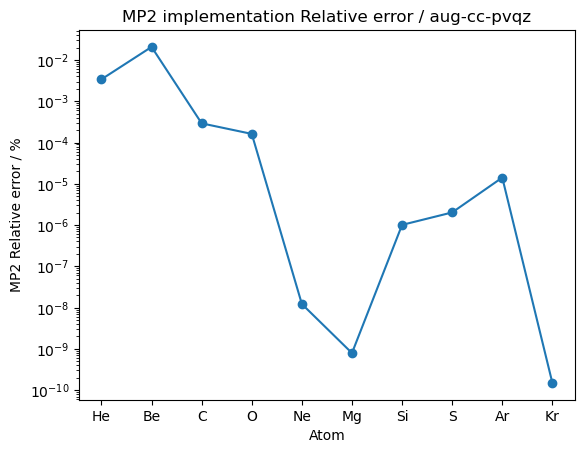

In [7]:
plt.plot(a_names, rel_errors, marker='o', linestyle='-')

plt.title(f'MP2 implementation Relative error / {basis}')
plt.yscale('log')
plt.ylabel('MP2 Relative error / %')
plt.xlabel('Atom')

plt.show()

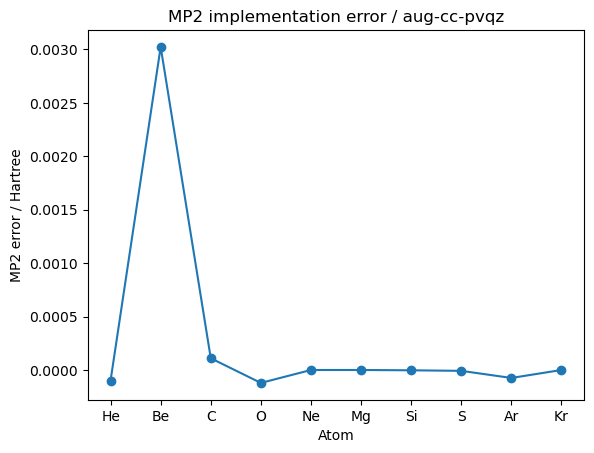

In [9]:
plt.plot(a_names, np.array(abs_errors).real, marker='o', linestyle='-')

plt.title(f'MP2 implementation error / {basis}')
# plt.yscale('log')
plt.ylabel('MP2 error / Hartree')
plt.xlabel('Atom')

plt.show()